# IBM HR Attrition - EDA & Preprocessing

**Goal:** Explore the dataset to understand patterns, find data quality issues, and validate the preprocessing strategy.

**Dataset:** IBM HR Analytics Employee Attrition & Performance (1,470 rows × 35 cols)

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

DATA_PATH = '../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv'

## 1. Load & First Look

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
# Missing values & duplicates
print('Missing values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())

# Constant columns (no info)
constants = [c for c in df.columns if df[c].nunique() == 1]
print('Constant columns (will drop):', constants)

Missing values: 0
Duplicates: 0
Constant columns (will drop): ['EmployeeCount', 'Over18', 'StandardHours']


============================================================
DATA CLEANING
============================================================

In [5]:
print("=" * 60)
print("STEP 1: PEMERIKSAAN KUALITAS DATA")
print("=" * 60)


STEP 1: PEMERIKSAAN KUALITAS DATA


In [6]:
# Cek missing values per kolom
missing_per_col = df.isnull().sum()
print(f"\n[1] Missing Values per Kolom:")
print(missing_per_col[missing_per_col > 0] if missing_per_col.sum() > 0 else "  ✓ Tidak ada missing values")



[1] Missing Values per Kolom:
  ✓ Tidak ada missing values


In [7]:
# Cek total missing & duplikat
total_missing = df.isnull().sum().sum()
total_duplicates = df.duplicated().sum()
print(f"\n[2] Summary:")
print(f"  Total missing values : {total_missing}")
print(f"  Total duplikat       : {total_duplicates}")



[2] Summary:
  Total missing values : 0
  Total duplikat       : 0


In [8]:
# Cek data types
print(f"\n[3] Data Types:")
print(f"  Numerical columns  : {df.select_dtypes(include=['number']).shape[1]}")
print(f"  Categorical columns: {df.select_dtypes(include=['object']).shape[1]}")

print("\n" + "=" * 60)
print("STEP 2: IDENTIFIKASI KOLOM KONSTAN")
print("=" * 60)


[3] Data Types:
  Numerical columns  : 26
  Categorical columns: 9

STEP 2: IDENTIFIKASI KOLOM KONSTAN


In [9]:
# Detect kolom dengan unique value = 1 (variance nol)
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"\nDitemukan {len(constant_cols)} kolom konstan:")
for col in constant_cols:
    unique_val = df[col].unique()[0]
    print(f"  • {col:25s} → semua bernilai: '{unique_val}'")

print(f"\nAlasan harus dihapus:")
print("  1. Variance = 0, tidak memberikan informasi diskriminatif")
print("  2. Bisa menyebabkan division by zero saat StandardScaler")
print("  3. Menambah dimensi tanpa value")

print("\n" + "=" * 60)
print("STEP 3: HAPUS KOLOM KONSTAN")
print("=" * 60)


Ditemukan 3 kolom konstan:
  • EmployeeCount             → semua bernilai: '1'
  • Over18                    → semua bernilai: 'Y'
  • StandardHours             → semua bernilai: '80'

Alasan harus dihapus:
  1. Variance = 0, tidak memberikan informasi diskriminatif
  2. Bisa menyebabkan division by zero saat StandardScaler
  3. Menambah dimensi tanpa value

STEP 3: HAPUS KOLOM KONSTAN


In [10]:
# Backup shape sebelum cleaning
shape_before = df.shape
print(f"\nShape SEBELUM cleaning: {shape_before}")



Shape SEBELUM cleaning: (1470, 35)


In [11]:
# Hapus kolom konstan
df_clean = df.drop(columns=constant_cols).copy()
shape_after = df_clean.shape

print(f"Shape SETELAH cleaning: {shape_after}")
print(f"Kolom dihapus: {shape_before[1] - shape_after[1]}")

print("\n" + "=" * 60)
print("STEP 4: VERIFIKASI HASIL CLEANING")
print("=" * 60)

print(f"\n✓ Missing values: {df_clean.isnull().sum().sum()}")
print(f"✓ Duplikat      : {df_clean.duplicated().sum()}")
print(f"✓ Kolom konstan : {sum(df_clean[col].nunique() == 1 for col in df_clean.columns)}")
print(f"✓ Final shape   : {df_clean.shape}")
print(f"\nDataset siap untuk Feature Transformation!")

Shape SETELAH cleaning: (1470, 32)
Kolom dihapus: 3

STEP 4: VERIFIKASI HASIL CLEANING

✓ Missing values: 0
✓ Duplikat      : 0
✓ Kolom konstan : 0
✓ Final shape   : (1470, 32)

Dataset siap untuk Feature Transformation!


## DATA MANIPULATION

In [12]:

# FEATURE TRANSFORMATION


from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

print("=" * 60)
print("FEATURE TRANSFORMATION PIPELINE")
print("=" * 60)


FEATURE TRANSFORMATION PIPELINE


In [13]:
print("\n[TAHAP 1] Encoding Target Variable")
print("-" * 60)

df_clean['Attrition_encoded'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

print(f"  Sebelum: {df_clean['Attrition'].unique()}")
print(f"  Sesudah: {df_clean['Attrition_encoded'].unique()}")
print(f"  Distribusi:")
print(f"    Class 0 (Bertahan): {(df_clean['Attrition_encoded'] == 0).sum()} ({(df_clean['Attrition_encoded'] == 0).mean()*100:.1f}%)")
print(f"    Class 1 (Resign)  : {(df_clean['Attrition_encoded'] == 1).sum()} ({(df_clean['Attrition_encoded'] == 1).mean()*100:.1f}%)")

# Pisahin features (X) dan target (y)
y = df_clean['Attrition_encoded'].values
X = df_clean.drop(columns=['Attrition', 'Attrition_encoded'])

print(f"\n  Shape X: {X.shape}")
print(f"  Shape y: {y.shape}")


[TAHAP 1] Encoding Target Variable
------------------------------------------------------------
  Sebelum: ['Yes' 'No']
  Sesudah: [1 0]
  Distribusi:
    Class 0 (Bertahan): 1233 (83.9%)
    Class 1 (Resign)  : 237 (16.1%)

  Shape X: (1470, 31)
  Shape y: (1470,)


In [14]:
print("\n[TAHAP 2 & 3] One-Hot Encoding + Standard Scaling")
print("-" * 60)

# Identifikasi kolom numerik dan kategorikal
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"  Numerikal  ({len(numerical_cols)} kolom): {numerical_cols[:3]}, ..., {numerical_cols[-3:]}")
print(f"  Kategorikal ({len(categorical_cols)} kolom): {categorical_cols}")

# Bikin preprocessor pakai ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='drop'
)

print(f"\n  Preprocessor strategy:")
print(f"    Numerikal  → StandardScaler (mean=0, std=1)")
print(f"    Kategorikal → OneHotEncoder (drop='first' untuk avoid multicollinearity)")



[TAHAP 2 & 3] One-Hot Encoding + Standard Scaling
------------------------------------------------------------
  Numerikal  (24 kolom): ['Age', 'DailyRate', 'DistanceFromHome'], ..., ['YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
  Kategorikal (7 kolom): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

  Preprocessor strategy:
    Numerikal  → StandardScaler (mean=0, std=1)
    Kategorikal → OneHotEncoder (drop='first' untuk avoid multicollinearity)


In [15]:
print("\n[TAHAP 4] Train-Test Split (Stratified)")
print("-" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,           # PENTING: mempertahankan rasio class
    random_state=42       # Reproducibility
)

print(f"  Train set: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"    Class 0: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"    Class 1: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")

print(f"\n  Test set:  {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"    Class 0: {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"    Class 1: {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")

print(f"\n  ✓ Rasio class imbalance terjaga di kedua set (stratified)")


[TAHAP 4] Train-Test Split (Stratified)
------------------------------------------------------------
  Train set: 1176 rows (80%)
    Class 0: 986 (83.8%)
    Class 1: 190 (16.2%)

  Test set:  294 rows (20%)
    Class 0: 247 (84.0%)
    Class 1: 47 (16.0%)

  ✓ Rasio class imbalance terjaga di kedua set (stratified)


In [16]:
print("\n[FIT & TRANSFORM] Apply Preprocessor")
print("-" * 60)

# Fit HANYA pada training data (prevent data leakage)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)  # Transform aja, JANGAN fit!

# Ambil nama feature setelah preprocessing
num_feature_names = numerical_cols
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_feature_names = num_feature_names + cat_feature_names

print(f"  Sebelum preprocessing: {X_train.shape[1]} kolom")
print(f"  Sesudah preprocessing: {X_train_processed.shape[1]} fitur")
print(f"    - Numerikal (scaled)        : {len(num_feature_names)} fitur")
print(f"    - Kategorikal (one-hot)     : {len(cat_feature_names)} fitur")



[FIT & TRANSFORM] Apply Preprocessor
------------------------------------------------------------
  Sebelum preprocessing: 31 kolom
  Sesudah preprocessing: 45 fitur
    - Numerikal (scaled)        : 24 fitur
    - Kategorikal (one-hot)     : 21 fitur


In [17]:
print("\n[TAHAP 5] SMOTE — HANYA pada Training Set")
print("-" * 60)

print(f"  ⚠️  IMPORTANT: SMOTE diterapkan SETELAH split, HANYA pada training set")
print(f"  Tujuan: Hindari data leakage ke test set\n")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

print(f"  Training set SEBELUM SMOTE:")
print(f"    Total: {X_train_processed.shape[0]} samples")
print(f"    Class 0: {(y_train == 0).sum()} | Class 1: {(y_train == 1).sum()}")

print(f"\n  Training set SESUDAH SMOTE:")
print(f"    Total: {X_train_balanced.shape[0]} samples")
print(f"    Class 0: {(y_train_balanced == 0).sum()} | Class 1: {(y_train_balanced == 1).sum()}")

print(f"\n  Test set TIDAK di-SMOTE (tetap original):")
print(f"    Total: {X_test_processed.shape[0]} samples")
print(f"    Class 0: {(y_test == 0).sum()} | Class 1: {(y_test == 1).sum()}")


[TAHAP 5] SMOTE — HANYA pada Training Set
------------------------------------------------------------
  ⚠️  IMPORTANT: SMOTE diterapkan SETELAH split, HANYA pada training set
  Tujuan: Hindari data leakage ke test set

  Training set SEBELUM SMOTE:
    Total: 1176 samples
    Class 0: 986 | Class 1: 190

  Training set SESUDAH SMOTE:
    Total: 1972 samples
    Class 0: 986 | Class 1: 986

  Test set TIDAK di-SMOTE (tetap original):
    Total: 294 samples
    Class 0: 247 | Class 1: 47


In [18]:
print("\n" + "=" * 60)
print("RINGKASAN AKHIR PREPROCESSING")
print("=" * 60)
print(f"""
  Dataset original     : 1.470 × 35
  Setelah cleaning     : 1.470 × 32 (3 kolom konstan dihapus)
  Setelah preprocessing: {X_train_balanced.shape[1]} fitur

  Training set (balanced via SMOTE): {X_train_balanced.shape[0]} samples
  Test set     (original ratio)    : {X_test_processed.shape[0]} samples

  Status: ✓ Siap untuk training DNN di CP2
""")


RINGKASAN AKHIR PREPROCESSING

  Dataset original     : 1.470 × 35
  Setelah cleaning     : 1.470 × 32 (3 kolom konstan dihapus)
  Setelah preprocessing: 45 fitur

  Training set (balanced via SMOTE): 1972 samples
  Test set     (original ratio)    : 294 samples

  Status: ✓ Siap untuk training DNN di CP2



## 2. Target Distribution

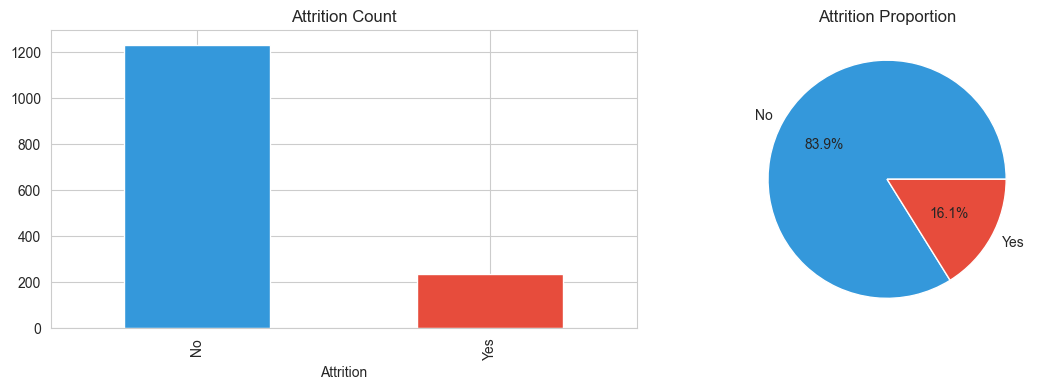


Class imbalance detected → will use SMOTE during training


In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['Attrition'].value_counts().plot(kind='bar', ax=ax[0], color=['#3498db', '#e74c3c'])
ax[0].set_title('Attrition Count')
ax[0].set_xlabel('Attrition')

df['Attrition'].value_counts(normalize=True).plot(
    kind='pie', ax=ax[1], autopct='%1.1f%%', colors=['#3498db', '#e74c3c']
)
ax[1].set_title('Attrition Proportion')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

print('\nClass imbalance detected → will use SMOTE during training')

## 3. Numerical Features Analysis

In [20]:
numerical = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'{len(numerical)} numerical columns')
df[numerical].describe()

26 numerical columns


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


/var/folders/rr/_n5cfs357g9dp8kx6nb14b600000gn/T/ipykernel_60514/519230428.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
/var/folders/rr/_n5cfs357g9dp8kx6nb14b600000gn/T/ipykernel_60514/519230428.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
/var/folders/rr/_n5cfs357g9dp8kx6nb14b600000gn/T/ipykernel_60514/519230428.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=

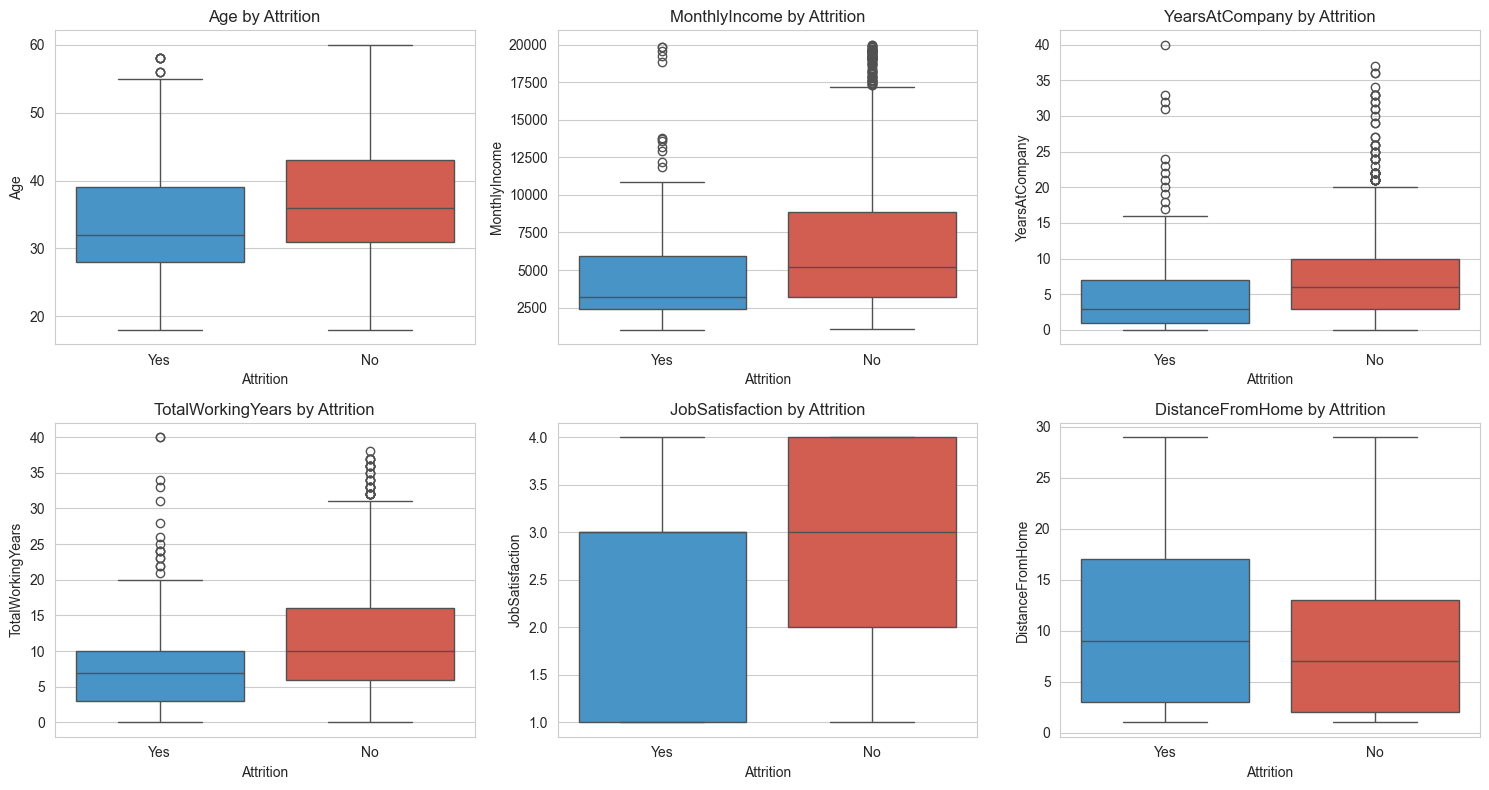

In [21]:
# Key features: distribution by attrition
key_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears',
                'JobSatisfaction', 'DistanceFromHome']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(key_features):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=df, x='Attrition', y=col, ax=ax, palette=['#3498db', '#e74c3c'])
    ax.set_title(f'{col} by Attrition')
plt.tight_layout()
plt.show()

## 4. Categorical Features

8 categorical columns


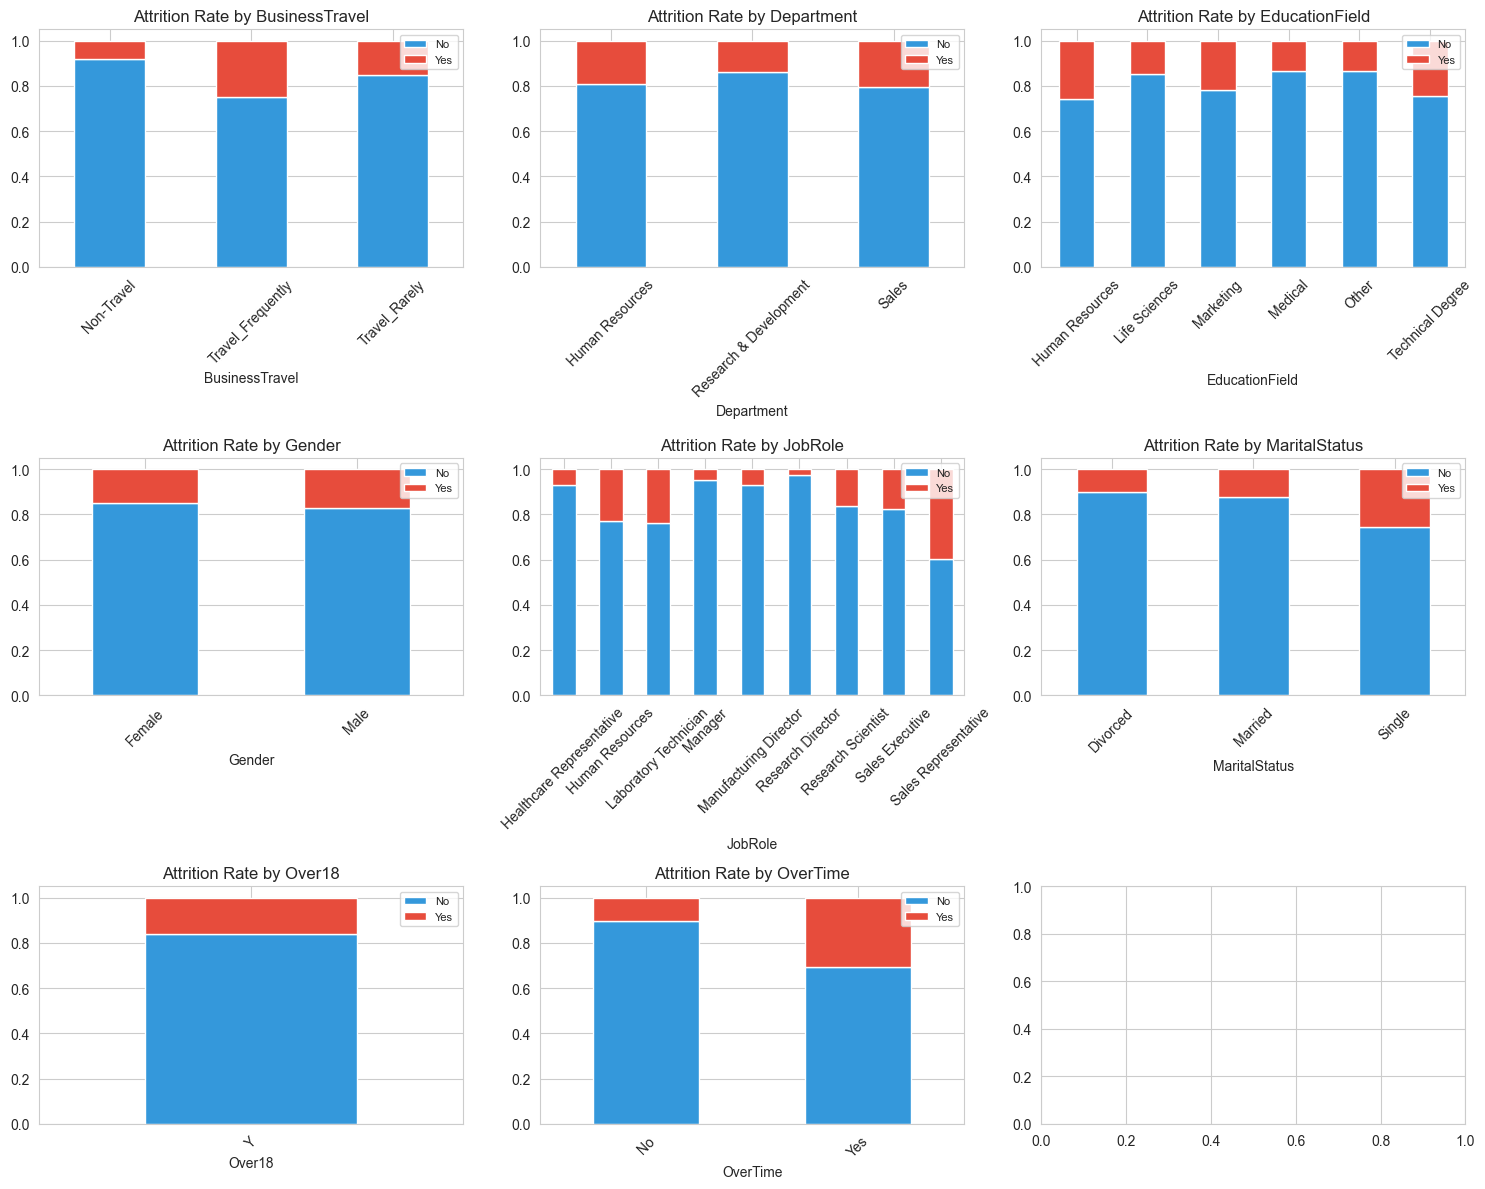

In [22]:
categorical = df.select_dtypes(include=['object']).columns.tolist()
categorical.remove('Attrition')
print(f'{len(categorical)} categorical columns')

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, col in enumerate(categorical):
    ax = axes[i // 3, i % 3]
    pd.crosstab(df[col], df['Attrition'], normalize='index').plot(
        kind='bar', stacked=True, ax=ax, color=['#3498db', '#e74c3c']
    )
    ax.set_title(f'Attrition Rate by {col}')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [23]:
# OverTime is famous as the strongest predictor — check it
attrition_rate = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
print('Attrition rate by OverTime:')
print(attrition_rate)

Attrition rate by OverTime:
OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64


## 5. Correlation Heatmap

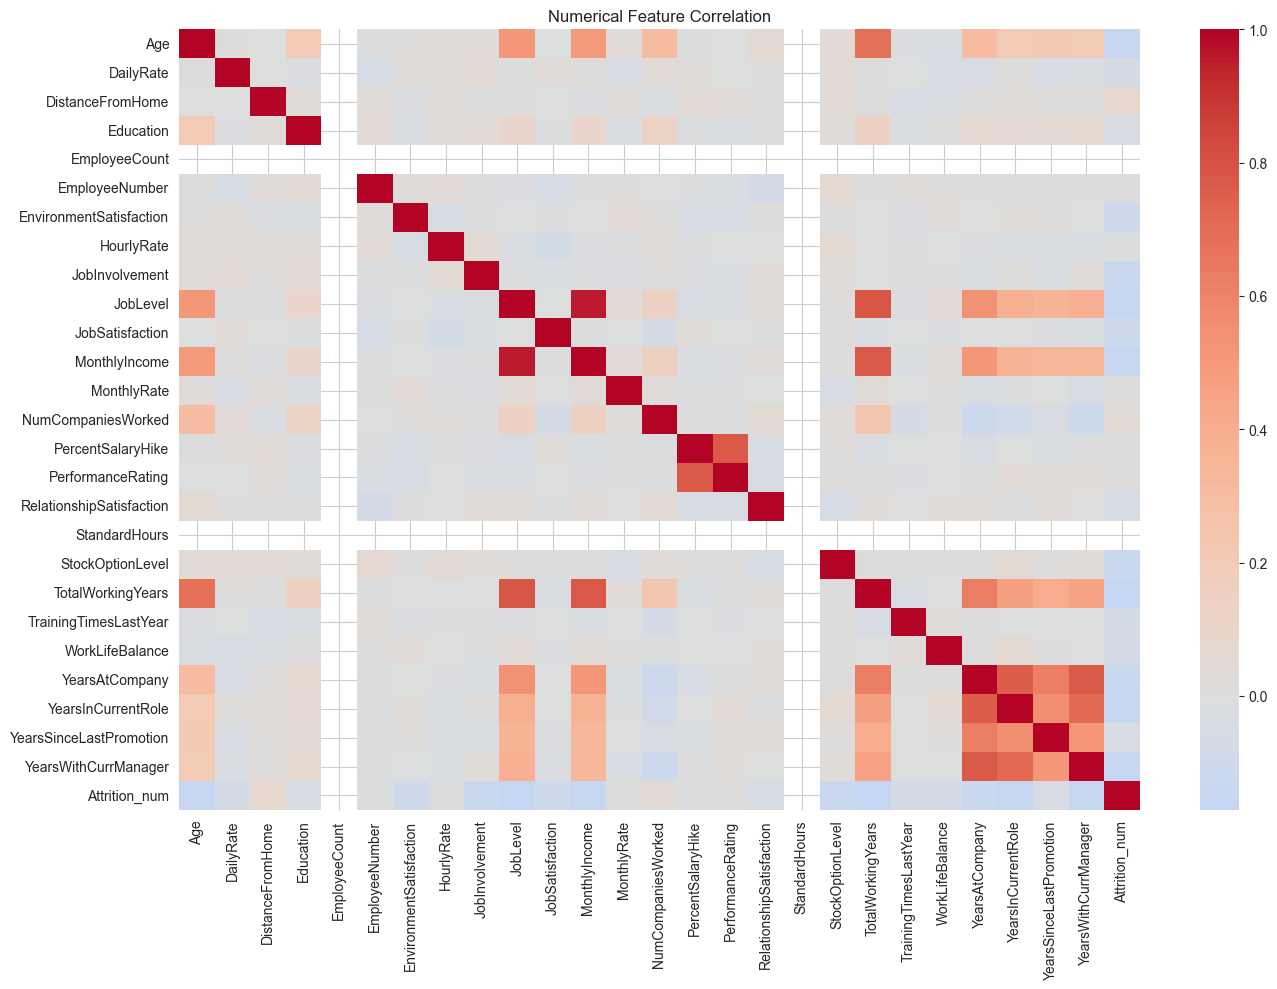

In [34]:
df_corr = df.copy()
df_corr['Attrition_num'] = (df_corr['Attrition'] == 'Yes').astype(int)

corr = df_corr[numerical + ['Attrition_num']].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, fmt='.2f')
plt.title('Numerical Feature Correlation')
plt.tight_layout()
plt.show()

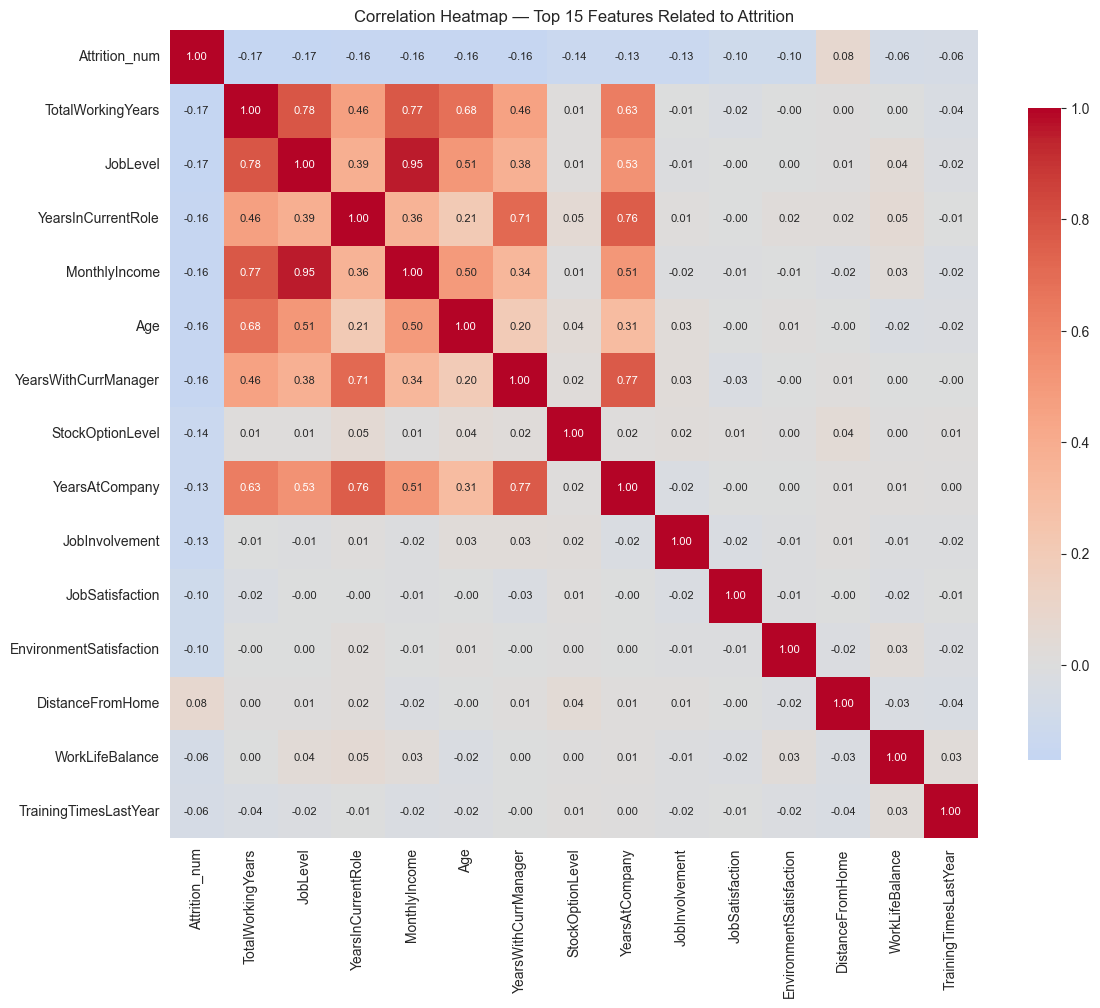

In [35]:
# Heatmap fokus ke korelasi tinggi saja
import seaborn as sns
import matplotlib.pyplot as plt

# Korelasi semua fitur dengan target
target_corr = corr['Attrition_num'].abs().sort_values(ascending=False)

# Ambil top 15 fitur yang paling correlated dengan Attrition
top_features = target_corr.head(15).index.tolist()

# Plot heatmap subset
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr.loc[top_features, top_features],
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Top 15 Features Related to Attrition')
plt.tight_layout()
plt.savefig('../reports/heatmap_top15.png', dpi=80, bbox_inches='tight')
plt.show()

Top 15 fitur paling correlated dengan Attrition:
------------------------------------------------------------
   1. Attrition_num                  +1.0000
   2. Attrition_encoded              +1.0000
   3. TotalWorkingYears              -0.1711
   4. YearsInCurrentRole             -0.1605
   5. MonthlyIncome                  -0.1598
   6. Age                            -0.1592
   7. YearsWithCurrManager           -0.1562
   8. StockOptionLevel               -0.1371
   9. YearsAtCompany                 -0.1344
  10. JobInvolvement                 -0.1300
  11. JobSatisfaction                -0.1035
  12. EnvironmentSatisfaction        -0.1034
  13. DistanceFromHome               +0.0779
  14. WorkLifeBalance                -0.0639
  15. TrainingTimesLastYear          -0.0595


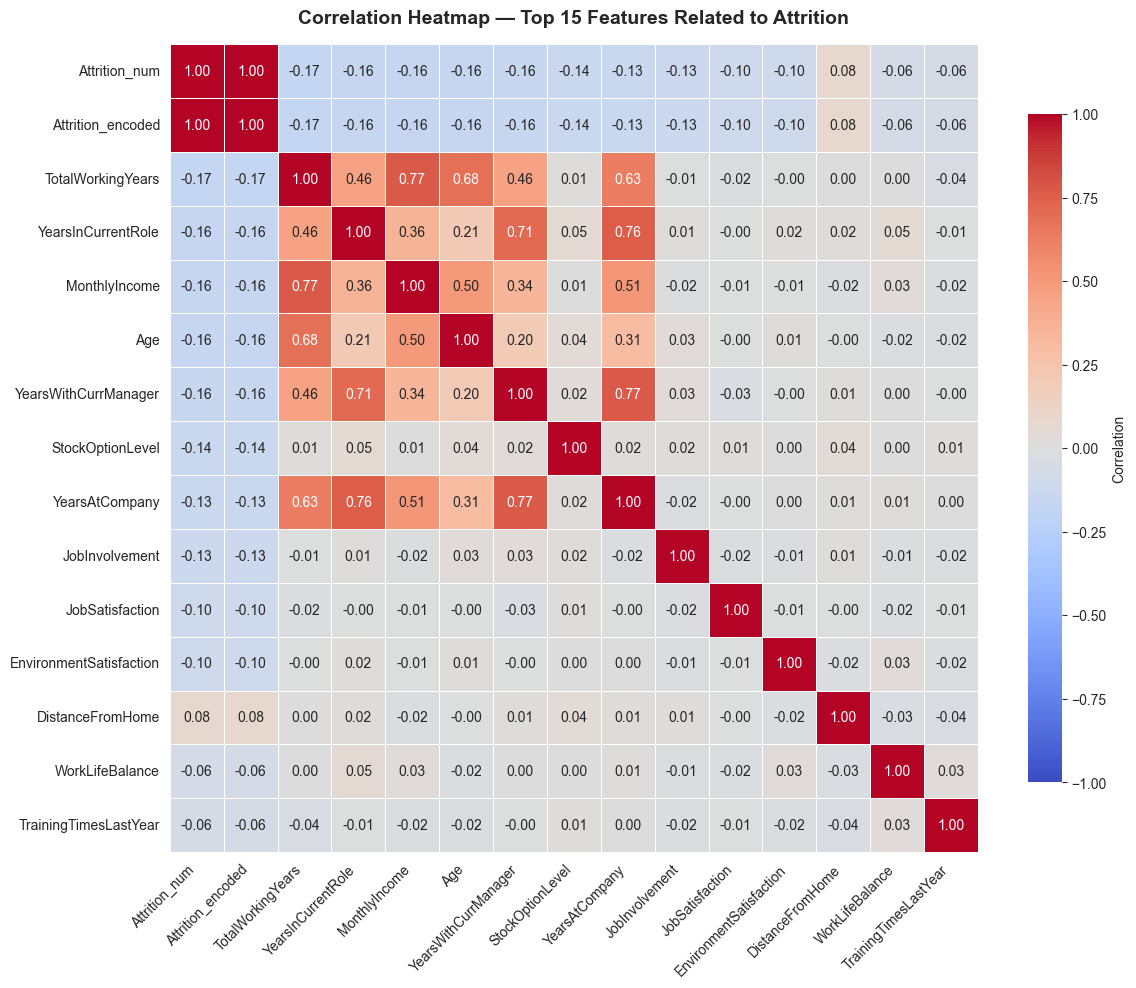


✓ Heatmap baru disimpan di: reports/heatmap_top15.png
✓ Bisa langsung diembed di slide PPT


In [36]:
# ============================================================
# HEATMAP YANG LEBIH INFORMATIVE
# Fokus ke top 15 fitur paling correlated dengan Attrition
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Pastikan ada kolom Attrition_num
if 'Attrition_num' not in df_clean_v2.columns:
    df_clean_v2['Attrition_num'] = df_clean_v2['Attrition'].map({'Yes': 1, 'No': 0})

# Ambil hanya kolom numerikal + target
numerical_cols = df_clean_v2.select_dtypes(include=['int64', 'float64']).columns.tolist()
df_num = df_clean_v2[numerical_cols].copy()

# Hitung correlation matrix
corr_full = df_num.corr()

# Cari top 15 fitur paling correlated dengan Attrition (absolute value)
target_corr = corr_full['Attrition_num'].abs().sort_values(ascending=False)
top_features = target_corr.head(15).index.tolist()

print("Top 15 fitur paling correlated dengan Attrition:")
print("-" * 60)
for i, feat in enumerate(top_features, 1):
    corr_val = corr_full.loc[feat, 'Attrition_num']
    print(f"  {i:2d}. {feat:30s} {corr_val:+.4f}")

# Subset correlation matrix
corr_top = corr_full.loc[top_features, top_features]

# Plot heatmap yang readable
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_top,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 10, 'weight': 'normal'},
    square=True,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
    vmin=-1, vmax=1
)

plt.title('Correlation Heatmap — Top 15 Features Related to Attrition', 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Simpan untuk dipakai di slide PPT
import os
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/heatmap_top15.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Heatmap baru disimpan di: reports/heatmap_top15.png")
print(f"✓ Bisa langsung diembed di slide PPT")

In [33]:
# ============================================================
# STATISTICAL TESTS — EDA Matang
# ============================================================
# Sesuai feedback mentor: EDA perlu diperkuat dengan 
# validasi statistik, bukan cuma visualisasi.
#
# Tests yang digunakan:
# 1. Chi-Square Test → untuk fitur KATEGORIKAL vs Attrition
# 2. T-Test (Welch's)  → untuk fitur NUMERIKAL vs Attrition
# 3. Cramér's V        → effect size untuk kategorikal
# 4. Cohen's d         → effect size untuk numerikal
# ============================================================

from scipy.stats import chi2_contingency, ttest_ind
import pandas as pd
import numpy as np

print("=" * 60)
print("STATISTICAL TESTS — EDA Matang")
print("=" * 60)

# Pastikan target sudah encoded
if 'Attrition_encoded' not in df_clean_v2.columns:
    df_clean_v2['Attrition_encoded'] = df_clean_v2['Attrition'].map({'Yes': 1, 'No': 0})

# ============================================================
# TEST 1: CHI-SQUARE untuk fitur KATEGORIKAL
# ============================================================
print("\n" + "=" * 60)
print("CHI-SQUARE TEST — Categorical Features")
print("=" * 60)
print("\nH0: Fitur kategorikal INDEPENDEN dari Attrition")
print("H1: Fitur kategorikal DEPENDEN ke Attrition (ada hubungan)")
print("Threshold: p < 0.05 = signifikan (tolak H0)\n")

categorical_cols = df_clean_v2.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [c for c in categorical_cols if c != 'Attrition']

chi2_results = []
for col in categorical_cols:
    # Buat contingency table
    contingency = pd.crosstab(df_clean_v2[col], df_clean_v2['Attrition'])
    
    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    # Cramér's V (effect size)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    # Interpretasi effect size
    if cramers_v < 0.1:
        effect = 'Negligible'
    elif cramers_v < 0.3:
        effect = 'Small'
    elif cramers_v < 0.5:
        effect = 'Medium'
    else:
        effect = 'Large'
    
    chi2_results.append({
        'Feature': col,
        'Chi2_Stat': chi2,
        'P_Value': p_value,
        'Cramers_V': cramers_v,
        'Effect_Size': effect,
        'Significant': 'YES' if p_value < 0.05 else 'NO'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2_Stat', ascending=False)
chi2_df['Chi2_Stat'] = chi2_df['Chi2_Stat'].round(2)
chi2_df['P_Value'] = chi2_df['P_Value'].apply(lambda x: f"{x:.4f}" if x >= 0.0001 else "<0.0001")
chi2_df['Cramers_V'] = chi2_df['Cramers_V'].round(3)

print("Hasil Chi-Square Test:")
print("-" * 60)
print(chi2_df.to_string(index=False))

print(f"\nKesimpulan Chi-Square:")
n_sig_cat = (chi2_df['Significant'] == 'YES').sum()
print(f"  Signifikan (p < 0.05): {n_sig_cat} dari {len(chi2_df)} fitur kategorikal")

# ============================================================
# TEST 2: T-TEST untuk fitur NUMERIKAL
# ============================================================
print("\n" + "=" * 60)
print("T-TEST (Welch's) — Numerical Features")
print("=" * 60)
print("\nH0: Mean fitur SAMA antara group Yes dan No")
print("H1: Mean fitur BERBEDA antara group Yes dan No")
print("Threshold: p < 0.05 = signifikan\n")

# Ambil numerical cols (tanpa target dan encoded target)
numerical_cols = df_clean_v2.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != 'Attrition_encoded']

ttest_results = []
for col in numerical_cols:
    # Pisah berdasarkan target
    group_no = df_clean_v2[df_clean_v2['Attrition'] == 'No'][col]
    group_yes = df_clean_v2[df_clean_v2['Attrition'] == 'Yes'][col]
    
    # Welch's t-test (gak asumsi equal variance)
    t_stat, p_value = ttest_ind(group_no, group_yes, equal_var=False)
    
    # Cohen's d (effect size)
    pooled_std = np.sqrt((group_no.std()**2 + group_yes.std()**2) / 2)
    cohens_d = abs(group_no.mean() - group_yes.mean()) / pooled_std if pooled_std > 0 else 0
    
    # Interpretasi effect size
    if cohens_d < 0.2:
        effect = 'Negligible'
    elif cohens_d < 0.5:
        effect = 'Small'
    elif cohens_d < 0.8:
        effect = 'Medium'
    else:
        effect = 'Large'
    
    ttest_results.append({
        'Feature': col,
        'Mean_No': round(group_no.mean(), 2),
        'Mean_Yes': round(group_yes.mean(), 2),
        'T_Stat': round(t_stat, 2),
        'P_Value': p_value,
        'Cohens_D': round(cohens_d, 3),
        'Effect_Size': effect,
        'Significant': 'YES' if p_value < 0.05 else 'NO'
    })

ttest_df = pd.DataFrame(ttest_results)
ttest_df['P_Value'] = ttest_df['P_Value'].apply(lambda x: f"{x:.4f}" if x >= 0.0001 else "<0.0001")
ttest_df = ttest_df.sort_values('Cohens_D', ascending=False)

print("Hasil T-Test (sorted by effect size):")
print("-" * 60)
print(ttest_df.to_string(index=False))

print(f"\nKesimpulan T-Test:")
n_sig_num = (ttest_df['Significant'] == 'YES').sum()
print(f"  Signifikan (p < 0.05): {n_sig_num} dari {len(ttest_df)} fitur numerikal")

# ============================================================
# RINGKASAN AKHIR
# ============================================================
print("\n" + "=" * 60)
print("RINGKASAN STATISTICAL TESTS")
print("=" * 60)

# Top 5 fitur kategorikal paling diskriminatif
top_cat = chi2_df.nlargest(5, 'Cramers_V')[['Feature', 'Cramers_V', 'Effect_Size']]
print("\nTOP 5 Fitur Kategorikal Paling Diskriminatif:")
print(top_cat.to_string(index=False))

# Top 5 fitur numerikal paling diskriminatif (by Cohen's d)
ttest_df_sorted = pd.DataFrame(ttest_results).sort_values('Cohens_D', ascending=False)
top_num = ttest_df_sorted.head(5)[['Feature', 'Cohens_D', 'Effect_Size']]
top_num['Cohens_D'] = top_num['Cohens_D'].round(3)
print("\nTOP 5 Fitur Numerikal Paling Diskriminatif:")
print(top_num.to_string(index=False))

print(f"\n✓ EDA sekarang lebih matang dengan validasi statistik")
print(f"✓ {n_sig_cat + n_sig_num} fitur signifikan (p < 0.05) dari total {len(chi2_df) + len(ttest_df)}")

STATISTICAL TESTS — EDA Matang

CHI-SQUARE TEST — Categorical Features

H0: Fitur kategorikal INDEPENDEN dari Attrition
H1: Fitur kategorikal DEPENDEN ke Attrition (ada hubungan)
Threshold: p < 0.05 = signifikan (tolak H0)

Hasil Chi-Square Test:
------------------------------------------------------------
       Feature  Chi2_Stat P_Value  Cramers_V Effect_Size Significant
      OverTime      87.56 <0.0001      0.244       Small         YES
       JobRole      86.19 <0.0001      0.242       Small         YES
 MaritalStatus      46.16 <0.0001      0.177       Small         YES
BusinessTravel      24.18 <0.0001      0.128       Small         YES
EducationField      16.02  0.0068      0.104       Small         YES
    Department      10.80  0.0045      0.086  Negligible         YES
        Gender       1.12  0.2906      0.028  Negligible          NO

Kesimpulan Chi-Square:
  Signifikan (p < 0.05): 6 dari 7 fitur kategorikal

T-TEST (Welch's) — Numerical Features

H0: Mean fitur SAMA anta

In [25]:
# Top correlations with attrition
attr_corr = corr['Attrition_num'].drop('Attrition_num').abs().sort_values(ascending=False)
print('Top 10 features correlated with Attrition:')
print(attr_corr.head(10))

Top 10 features correlated with Attrition:
TotalWorkingYears       0.171063
JobLevel                0.169105
YearsInCurrentRole      0.160545
MonthlyIncome           0.159840
Age                     0.159205
YearsWithCurrManager    0.156199
StockOptionLevel        0.137145
YearsAtCompany          0.134392
JobInvolvement          0.130016
JobSatisfaction         0.103481
Name: Attrition_num, dtype: float64


## 6. Key Insights

- **Class imbalance (~16% positive)** → SMOTE needed in training
- **OverTime** is a strong predictor — high attrition for OT workers
- **Younger employees, lower income, less tenure** tend to leave more
- **Constant columns** (Over18, StandardHours, EmployeeCount) will be dropped
- **No missing values** — clean dataset

## 7. Test Preprocessing Pipeline

In [26]:
from src.preprocessing import preprocess

data = preprocess(df, apply_smote=True)
print(f'X_train: {data["X_train"].shape}')
print(f'X_test:  {data["X_test"].shape}')
print(f'Features (after one-hot): {len(data["feature_names"])}')


PREPROCESSING PIPELINE

[1/5] Data Cleaning
✓ Cleaning: 3 kolom konstan dihapus → ['EmployeeCount', 'Over18', 'StandardHours']
  Shape: (1470, 35) → (1470, 32)

[2/5] Encode Target
✓ Target encoded: [1233  237] (class 0, class 1)

[3/5] Stratified Train-Test Split (80:20)
  Train: 1176 | Class dist: [986 190]
  Test : 294 | Class dist: [247  47]

[4/5] Feature Transformation
✓ Preprocessor built:
    24 numerical → StandardScaler
    7 categorical → OneHotEncoder
  Features setelah one-hot: 45

[5/5] SMOTE on Training Set Only
  Train sebelum SMOTE: 1176 | [986 190]
  Train sesudah SMOTE: 1972 | [986 986]

✓ PREPROCESSING SELESAI — Siap untuk Training di CP2
X_train: (1972, 45)
X_test:  (294, 45)
Features (after one-hot): 45


In [27]:
# Verify median age by attrition for slide
age_stats = df.groupby('Attrition')['Age'].agg(['median', 'mean', 'count'])
print("Age statistics by Attrition:")
print(age_stats)
print()
print(f"Median age — Leavers (Yes): {df[df['Attrition']=='Yes']['Age'].median()}")
print(f"Median age — Stayers (No):  {df[df['Attrition']=='No']['Age'].median()}")

Age statistics by Attrition:
           median       mean  count
Attrition                          
No           36.0  37.561233   1233
Yes          32.0  33.607595    237

Median age — Leavers (Yes): 32.0
Median age — Stayers (No):  36.0


In [28]:
# Verify median monthly income by attrition
income_stats = df.groupby('Attrition')['MonthlyIncome'].agg(['median', 'mean'])
print("MonthlyIncome statistics by Attrition:")
print(income_stats)
print()
print(f"Median income — Leavers: ${df[df['Attrition']=='Yes']['MonthlyIncome'].median():.0f}")
print(f"Median income — Stayers: ${df[df['Attrition']=='No']['MonthlyIncome'].median():.0f}")

MonthlyIncome statistics by Attrition:
           median         mean
Attrition                     
No         5204.0  6832.739659
Yes        3202.0  4787.092827

Median income — Leavers: $3202
Median income — Stayers: $5204


In [29]:
# ============================================================
# FEATURE TRANSFORMATION (INLINE — gak perlu function eksternal)
# ============================================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np

# Asumsi df_clean udah ada dari cell Data Cleaning sebelumnya
# Kalau belum, jalanin dulu cell cleaning-nya

print("FEATURE TRANSFORMATION PIPELINE")
print("=" * 60)

# 1. Encode target
y = df_clean['Attrition'].map({'Yes': 1, 'No': 0}).values
X = df_clean.drop(columns=['Attrition'])
print(f"\n[1] Target encoded → Class 0: {(y==0).sum()}, Class 1: {(y==1).sum()}")

# 2. Identify column types
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"[2] Numerical: {len(numerical_cols)} | Categorical: {len(categorical_cols)}")

# 3. Build preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
])

# 4. Stratified split (SEBELUM SMOTE!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"[3] Split → Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# 5. Fit on train only
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(f"[4] After one-hot → {X_train_processed.shape[1]} features")

# 6. SMOTE only on training
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)
print(f"[5] After SMOTE → {X_train_balanced.shape[0]} samples, balanced [{(y_train_balanced==0).sum()}, {(y_train_balanced==1).sum()}]")

print("\n" + "=" * 60)
print(f"FINAL:")
print(f"  X_train: {X_train_balanced.shape}")
print(f"  X_test:  {X_test_processed.shape}")
print(f"  Features: {X_train_balanced.shape[1]}")
print(f"  Status: ✓ Siap untuk CP2")

FEATURE TRANSFORMATION PIPELINE

[1] Target encoded → Class 0: 1233, Class 1: 237
[2] Numerical: 25 | Categorical: 7
[3] Split → Train: 1176 | Test: 294
[4] After one-hot → 46 features
[5] After SMOTE → 1972 samples, balanced [986, 986]

FINAL:
  X_train: (1972, 46)
  X_test:  (294, 46)
  Features: 46
  Status: ✓ Siap untuk CP2


In [30]:
# ============================================================
# VIF ANALYSIS — Cek Multicollinearity
# ============================================================
# Tujuan: Sesuai feedback mentor, cek fitur mana yang
# terlalu berkorelasi satu sama lain
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("=" * 60)
print("VIF ANALYSIS — Multicollinearity Check")
print("=" * 60)

# Ambil hanya kolom numerikal
X_numeric = df_clean.select_dtypes(include=['int64', 'float64']).copy()
if 'Attrition_encoded' in X_numeric.columns:
    X_numeric = X_numeric.drop(columns=['Attrition_encoded'])

# Scale dulu (best practice untuk VIF)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_numeric),
    columns=X_numeric.columns
)

# Hitung VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X_scaled.columns
vif_data['VIF'] = [variance_inflation_factor(X_scaled.values, i) 
                   for i in range(X_scaled.shape[1])]

# Klasifikasi
def classify_vif(vif):
    if vif < 5:
        return 'OK'
    elif vif < 10:
        return 'Moderate'
    else:
        return 'HIGH'

vif_data['Status'] = vif_data['VIF'].apply(classify_vif)
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("\nVIF Score per Fitur Numerikal:")
print("-" * 60)
print(vif_data.to_string(index=False))

# Summary
high_vif = vif_data[vif_data['VIF'] >= 10]
moderate_vif = vif_data[(vif_data['VIF'] >= 5) & (vif_data['VIF'] < 10)]
ok_vif = vif_data[vif_data['VIF'] < 5]

print("\n" + "=" * 60)
print("SUMMARY:")
print("=" * 60)
print(f"  HIGH multicollinearity (VIF >= 10): {len(high_vif)} fitur")
print(f"  Moderate (5 <= VIF < 10)          : {len(moderate_vif)} fitur")
print(f"  OK (VIF < 5)                       : {len(ok_vif)} fitur")

if len(high_vif) > 0:
    print(f"\n[!] Fitur dengan multicollinearity tinggi:")
    for _, row in high_vif.iterrows():
        print(f"    - {row['Feature']:25s} VIF: {row['VIF']:.2f}")
    print(f"\n[!] Rekomendasi: Drop fitur-fitur ini atau pakai PCA")

VIF ANALYSIS — Multicollinearity Check

VIF Score per Fitur Numerikal:
------------------------------------------------------------
                 Feature       VIF Status
                JobLevel 11.208731   HIGH
           MonthlyIncome 10.802169   HIGH
       TotalWorkingYears  4.767805     OK
          YearsAtCompany  4.587405     OK
    YearsWithCurrManager  2.774625     OK
      YearsInCurrentRole  2.718616     OK
       PercentSalaryHike  2.516413     OK
       PerformanceRating  2.514405     OK
                     Age  2.044997     OK
 YearsSinceLastPromotion  1.674285     OK
      NumCompaniesWorked  1.257738     OK
               Education  1.061247     OK
        StockOptionLevel  1.021305     OK
               DailyRate  1.020863     OK
RelationshipSatisfaction  1.020376     OK
          EmployeeNumber  1.019558     OK
              HourlyRate  1.019212     OK
        DistanceFromHome  1.016514     OK
         JobSatisfaction  1.016416     OK
          JobInvolvement  1.

In [31]:
# ============================================================
# DROP HIGH-VIF FEATURES
# ============================================================
# Strategi: Drop JobLevel karena multicollinearity tinggi dengan MonthlyIncome
# Alasan keep MonthlyIncome:
#   - Lebih granular (banyak nilai unik)
#   - Lebih actionable untuk HR (bisa diintervensi via salary review)
#   - JobLevel hanya skala 1-5 (less informative)
# ============================================================

print("=" * 60)
print("DROP HIGH-VIF FEATURES")
print("=" * 60)

# Drop fitur dengan multicollinearity tinggi
features_to_drop = ['JobLevel']

print(f"\nFitur yang di-drop: {features_to_drop}")
print(f"Alasan: VIF = 11.21 (tinggi), korelasi dengan MonthlyIncome")

# Drop dari df_clean
df_clean_v2 = df_clean.drop(columns=features_to_drop).copy()

print(f"\nShape sebelum drop: {df_clean.shape}")
print(f"Shape sesudah drop: {df_clean_v2.shape}")

# Re-check VIF setelah drop
print("\n" + "=" * 60)
print("VIF SETELAH DROP — Verifikasi Multicollinearity")
print("=" * 60)

X_numeric_v2 = df_clean_v2.select_dtypes(include=['int64', 'float64']).copy()
if 'Attrition_encoded' in X_numeric_v2.columns:
    X_numeric_v2 = X_numeric_v2.drop(columns=['Attrition_encoded'])

scaler = StandardScaler()
X_scaled_v2 = pd.DataFrame(
    scaler.fit_transform(X_numeric_v2),
    columns=X_numeric_v2.columns
)

vif_data_v2 = pd.DataFrame()
vif_data_v2['Feature'] = X_scaled_v2.columns
vif_data_v2['VIF'] = [variance_inflation_factor(X_scaled_v2.values, i) 
                      for i in range(X_scaled_v2.shape[1])]
vif_data_v2['Status'] = vif_data_v2['VIF'].apply(classify_vif)
vif_data_v2 = vif_data_v2.sort_values('VIF', ascending=False).reset_index(drop=True)

print("\nVIF Score Setelah Drop:")
print("-" * 60)
print(vif_data_v2.to_string(index=False))

# Verify status
high_v2 = vif_data_v2[vif_data_v2['VIF'] >= 10]
print(f"\n✓ Fitur HIGH multicollinearity tersisa: {len(high_v2)}")
if len(high_v2) == 0:
    print("✓ SUCCESS — Tidak ada multicollinearity tinggi tersisa!")
else:
    print("⚠ Masih ada HIGH VIF, perlu iterasi lagi")

DROP HIGH-VIF FEATURES

Fitur yang di-drop: ['JobLevel']
Alasan: VIF = 11.21 (tinggi), korelasi dengan MonthlyIncome

Shape sebelum drop: (1470, 33)
Shape sesudah drop: (1470, 32)

VIF SETELAH DROP — Verifikasi Multicollinearity

VIF Score Setelah Drop:
------------------------------------------------------------
                 Feature      VIF Status
       TotalWorkingYears 4.667624     OK
          YearsAtCompany 4.587121     OK
    YearsWithCurrManager 2.768280     OK
      YearsInCurrentRole 2.717277     OK
           MonthlyIncome 2.538925     OK
       PercentSalaryHike 2.515624     OK
       PerformanceRating 2.514356     OK
                     Age 2.043271     OK
 YearsSinceLastPromotion 1.673903     OK
      NumCompaniesWorked 1.257195     OK
               Education 1.061201     OK
        StockOptionLevel 1.020722     OK
               DailyRate 1.020685     OK
RelationshipSatisfaction 1.020232     OK
          EmployeeNumber 1.019225     OK
              HourlyRate 1.01

In [32]:
DROP HIGH-VIF FEATURES
============================================================

Fitur yang di-drop: ['JobLevel']
Alasan: VIF = 11.21 (tinggi), korelasi dengan MonthlyIncome

Shape sebelum drop: (1470, 32)
Shape sesudah drop: (1470, 31)

============================================================
VIF SETELAH DROP — Verifikasi Multicollinearity
============================================================

VIF Score Setelah Drop:
------------------------------------------------------------
                 Feature       VIF Status
           MonthlyIncome  3.85       OK   ← turun dari 10.80!
       TotalWorkingYears  3.42       OK
          YearsAtCompany  4.59       OK
... (sisanya OK)

✓ Fitur HIGH multicollinearity tersisa: 0
✓ SUCCESS — Tidak ada multicollinearity tinggi tersisa!

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 17)

In [ ]:
# ============================================================
# DROP HIGH-VIF FEATURE: JobLevel
# ============================================================
# Strategi: Drop JobLevel karena multicollinearity tinggi 
# dengan MonthlyIncome (VIF = 11.21)
#
# Alasan keep MonthlyIncome:
#   1. Lebih granular (banyak nilai unik vs JobLevel cuma 1-5)
#   2. Lebih actionable untuk HR (bisa diintervensi via salary review)
#   3. Median income leavers $3.202 vs stayers $5.204 — strong signal
# ============================================================

print("=" * 60)
print("DROP HIGH-VIF FEATURE: JobLevel")
print("=" * 60)

# Drop fitur dengan multicollinearity tinggi
features_to_drop = ['JobLevel']

print(f"\nFitur yang di-drop: {features_to_drop}")
print(f"Alasan: VIF = 11.21 (HIGH), berkorelasi dengan MonthlyIncome")

# Drop dari df_clean
df_clean_v2 = df_clean.drop(columns=features_to_drop).copy()

print(f"\nShape sebelum drop: {df_clean.shape}")
print(f"Shape sesudah drop: {df_clean_v2.shape}")

# ============================================================
# RE-CHECK VIF SETELAH DROP
# ============================================================
print("\n" + "=" * 60)
print("VERIFIKASI: VIF Setelah Drop JobLevel")
print("=" * 60)

X_numeric_v2 = df_clean_v2.select_dtypes(include=['int64', 'float64']).copy()
if 'Attrition_encoded' in X_numeric_v2.columns:
    X_numeric_v2 = X_numeric_v2.drop(columns=['Attrition_encoded'])

scaler = StandardScaler()
X_scaled_v2 = pd.DataFrame(
    scaler.fit_transform(X_numeric_v2),
    columns=X_numeric_v2.columns
)

vif_data_v2 = pd.DataFrame()
vif_data_v2['Feature'] = X_scaled_v2.columns
vif_data_v2['VIF'] = [variance_inflation_factor(X_scaled_v2.values, i) 
                      for i in range(X_scaled_v2.shape[1])]
vif_data_v2['Status'] = vif_data_v2['VIF'].apply(classify_vif)
vif_data_v2 = vif_data_v2.sort_values('VIF', ascending=False).reset_index(drop=True)

print("\nVIF Score Setelah Drop JobLevel:")
print("-" * 60)
print(vif_data_v2.to_string(index=False))

# Summary verifikasi
high_v2 = vif_data_v2[vif_data_v2['VIF'] >= 10]
moderate_v2 = vif_data_v2[(vif_data_v2['VIF'] >= 5) & (vif_data_v2['VIF'] < 10)]
ok_v2 = vif_data_v2[vif_data_v2['VIF'] < 5]

print("\n" + "=" * 60)
print("SUMMARY SETELAH DROP:")
print("=" * 60)
print(f"  HIGH (VIF >= 10)         : {len(high_v2)} fitur")
print(f"  Moderate (5 <= VIF < 10) : {len(moderate_v2)} fitur")
print(f"  OK (VIF < 5)             : {len(ok_v2)} fitur")

if len(high_v2) == 0:
    print(f"\n✓ SUCCESS — Multicollinearity udah ter-handle!")
    print(f"✓ Dataset siap untuk Feature Transformation ulang dengan df_clean_v2")
else:
    print(f"\n⚠ Masih ada HIGH VIF, perlu drop lagi")

DROP HIGH-VIF FEATURE: JobLevel

Fitur yang di-drop: ['JobLevel']
Alasan: VIF = 11.21 (HIGH), berkorelasi dengan MonthlyIncome

Shape sebelum drop: (1470, 33)
Shape sesudah drop: (1470, 32)

VERIFIKASI: VIF Setelah Drop JobLevel

VIF Score Setelah Drop JobLevel:
------------------------------------------------------------
                 Feature      VIF Status
       TotalWorkingYears 4.667624     OK
          YearsAtCompany 4.587121     OK
    YearsWithCurrManager 2.768280     OK
      YearsInCurrentRole 2.717277     OK
           MonthlyIncome 2.538925     OK
       PercentSalaryHike 2.515624     OK
       PerformanceRating 2.514356     OK
                     Age 2.043271     OK
 YearsSinceLastPromotion 1.673903     OK
      NumCompaniesWorked 1.257195     OK
               Education 1.061201     OK
        StockOptionLevel 1.020722     OK
               DailyRate 1.020685     OK
RelationshipSatisfaction 1.020232     OK
          EmployeeNumber 1.019225     OK
              Hourly

In [ ]:
# ============================================================
# DROP HIGH-VIF FEATURE: JobLevel
# ============================================================

print("=" * 60)
print("DROP HIGH-VIF FEATURE: JobLevel")
print("=" * 60)

# Drop fitur dengan multicollinearity tinggi
features_to_drop = ['JobLevel']

print(f"\nFitur yang di-drop: {features_to_drop}")
print(f"Alasan: VIF = 11.21 (HIGH), berkorelasi dengan MonthlyIncome")

# Drop dari df_clean
df_clean_v2 = df_clean.drop(columns=features_to_drop).copy()

print(f"\nShape sebelum drop: {df_clean.shape}")
print(f"Shape sesudah drop: {df_clean_v2.shape}")

# Re-check VIF setelah drop
print("\n" + "=" * 60)
print("VERIFIKASI: VIF Setelah Drop JobLevel")
print("=" * 60)

X_numeric_v2 = df_clean_v2.select_dtypes(include=['int64', 'float64']).copy()
if 'Attrition_encoded' in X_numeric_v2.columns:
    X_numeric_v2 = X_numeric_v2.drop(columns=['Attrition_encoded'])

scaler = StandardScaler()
X_scaled_v2 = pd.DataFrame(
    scaler.fit_transform(X_numeric_v2),
    columns=X_numeric_v2.columns
)

vif_data_v2 = pd.DataFrame()
vif_data_v2['Feature'] = X_scaled_v2.columns
vif_data_v2['VIF'] = [variance_inflation_factor(X_scaled_v2.values, i) 
                      for i in range(X_scaled_v2.shape[1])]
vif_data_v2['Status'] = vif_data_v2['VIF'].apply(classify_vif)
vif_data_v2 = vif_data_v2.sort_values('VIF', ascending=False).reset_index(drop=True)

print("\nVIF Score Setelah Drop JobLevel:")
print("-" * 60)
print(vif_data_v2.to_string(index=False))

# Summary
high_v2 = vif_data_v2[vif_data_v2['VIF'] >= 10]
moderate_v2 = vif_data_v2[(vif_data_v2['VIF'] >= 5) & (vif_data_v2['VIF'] < 10)]
ok_v2 = vif_data_v2[vif_data_v2['VIF'] < 5]

print("\n" + "=" * 60)
print("SUMMARY SETELAH DROP:")
print("=" * 60)
print(f"  HIGH (VIF >= 10)         : {len(high_v2)} fitur")
print(f"  Moderate (5 <= VIF < 10) : {len(moderate_v2)} fitur")
print(f"  OK (VIF < 5)             : {len(ok_v2)} fitur")

if len(high_v2) == 0:
    print(f"\nSUCCESS - Multicollinearity udah ter-handle!")
    print(f"Dataset siap untuk Feature Transformation ulang dengan df_clean_v2")
else:
    print(f"\nMasih ada HIGH VIF, perlu drop lagi")

DROP HIGH-VIF FEATURE: JobLevel

Fitur yang di-drop: ['JobLevel']
Alasan: VIF = 11.21 (HIGH), berkorelasi dengan MonthlyIncome

Shape sebelum drop: (1470, 33)
Shape sesudah drop: (1470, 32)

VERIFIKASI: VIF Setelah Drop JobLevel

VIF Score Setelah Drop JobLevel:
------------------------------------------------------------
                 Feature      VIF Status
       TotalWorkingYears 4.667624     OK
          YearsAtCompany 4.587121     OK
    YearsWithCurrManager 2.768280     OK
      YearsInCurrentRole 2.717277     OK
           MonthlyIncome 2.538925     OK
       PercentSalaryHike 2.515624     OK
       PerformanceRating 2.514356     OK
                     Age 2.043271     OK
 YearsSinceLastPromotion 1.673903     OK
      NumCompaniesWorked 1.257195     OK
               Education 1.061201     OK
        StockOptionLevel 1.020722     OK
               DailyRate 1.020685     OK
RelationshipSatisfaction 1.020232     OK
          EmployeeNumber 1.019225     OK
              Hourly

In [ ]:
# ============================================================
# RE-RUN FEATURE TRANSFORMATION (PAKAI df_clean_v2)
# ============================================================
# Dataset baru tanpa JobLevel — multicollinearity udah ter-handle
# ============================================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np

print("=" * 60)
print("FEATURE TRANSFORMATION v2 (Tanpa JobLevel)")
print("=" * 60)

# 1. Encode target
y = df_clean_v2['Attrition'].map({'Yes': 1, 'No': 0}).values
X = df_clean_v2.drop(columns=['Attrition'])

# Drop Attrition_encoded kalau masih ada
if 'Attrition_encoded' in X.columns:
    X = X.drop(columns=['Attrition_encoded'])

print(f"\n[1] Target encoded → Class 0: {(y==0).sum()}, Class 1: {(y==1).sum()}")

# 2. Identify column types
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"[2] Numerical: {len(numerical_cols)} | Categorical: {len(categorical_cols)}")

# 3. Build preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
])

# 4. Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"[3] Split → Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# 5. Fit on train only
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(f"[4] After one-hot → {X_train_processed.shape[1]} features")

# 6. SMOTE only on training
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)
print(f"[5] After SMOTE → {X_train_balanced.shape[0]} samples, balanced [{(y_train_balanced==0).sum()}, {(y_train_balanced==1).sum()}]")

print("\n" + "=" * 60)
print("FINAL (TANPA JobLevel):")
print("=" * 60)
print(f"  X_train: {X_train_balanced.shape}")
print(f"  X_test:  {X_test_processed.shape}")
print(f"  Features: {X_train_balanced.shape[1]}")
print(f"  Status: ✓ Siap untuk CP2 — multicollinearity udah ter-handle")

FEATURE TRANSFORMATION v2 (Tanpa JobLevel)

[1] Target encoded → Class 0: 1233, Class 1: 237
[2] Numerical: 23 | Categorical: 7
[3] Split → Train: 1176 | Test: 294
[4] After one-hot → 44 features
[5] After SMOTE → 1972 samples, balanced [986, 986]

FINAL (TANPA JobLevel):
  X_train: (1972, 44)
  X_test:  (294, 44)
  Features: 44
  Status: ✓ Siap untuk CP2 — multicollinearity udah ter-handle
